In [12]:
#!pip install --upgrade numpy scipy scikit-learn

import pandas as pd
import numpy as np
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from sklearn.model_selection import train_test_split


In [13]:
df = pd.read_csv("BostonHousing.csv")
df.head(10)

,crim,zn,indus,chas,nox,rm,age,dis,rad,tax,ptratio,b,lstat,medv
0,0.00632,18.0,2.31,0,0.538,6.575,65.2,4.0900,1,296,15.3,396.90,4.98,24.0
1,0.02731,0.0,7.07,0,0.469,6.421,78.9,4.9671,2,242,17.8,396.90,9.14,21.6
2,0.02729,0.0,7.07,0,0.469,7.185,61.1,4.9671,2,242,17.8,392.83,4.03,34.7
3,0.03237,0.0,2.18,0,0.458,6.998,45.8,6.0622,3,222,18.7,394.63,2.94,33.4
4,0.06905,0.0,2.18,0,0.458,7.147,54.2,6.0622,3,222,18.7,396.90,5.33,36.2
5,0.02985,0.0,2.18,0,0.458,6.430,58.7,6.0622,3,222,18.7,394.12,5.21,28.7
6,0.08829,12.5,7.87,0,0.524,6.012,66.6,5.5605,5,311,15.2,395.60,12.43,22.9
7,0.14455,12.5,7.87,0,0.524,6.172,96.1,5.9505,5,311,15.2,396.90,19.15,27.1
8,0.21124,12.5,7.87,0,0.524,5.631,100.0,6.0821,5,311,15.2,386.63,29.93,16.5
9,0.17004,12.5,7.87,0,0.524,6.004,85.9,6.5921,5,311,15.2,386.71,17.10,18.9


In [14]:
x = df.loc[:,df.columns!='medv']
y = df.loc[:,df.columns=='medv']

In [15]:
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.3,random_state=123)

In [19]:
mms=MinMaxScaler()
mms.fit(x_train)
x_train=mms.transform(x_train)
x_test=mms.transform(x_test)
x_train[:5],x_test[:5]

(array([[2.34782498e-03, 2.00000000e-01, 2.38269795e-01, 1.00000000e+00,
         1.50313152e-01, 7.99767622e-01, 4.87234043e-01, 2.91802800e-01,
         8.69565217e-02, 6.87022901e-02, 6.38297872e-01, 9.84542841e-01,
         1.37588652e-01],
        [4.56256121e-04, 2.10000000e-01, 1.89882698e-01, 0.00000000e+00,
         9.81210856e-02, 5.71262587e-01, 1.60638298e-01, 5.15231716e-01,
         1.30434783e-01, 1.06870229e-01, 4.46808511e-01, 1.00000000e+00,
         1.00709220e-01],
        [6.28012552e-04, 0.00000000e+00, 7.33137830e-02, 0.00000000e+00,
         2.00417537e-01, 5.00193648e-01, 5.97872340e-01, 1.30395897e-01,
         8.69565217e-02, 1.14503817e-02, 5.53191489e-01, 1.00000000e+00,
         2.19007092e-01],
        [5.70703456e-02, 0.00000000e+00, 6.46627566e-01, 0.00000000e+00,
         6.70146138e-01, 5.29821844e-01, 9.12765957e-01, 1.09432895e-01,
         1.00000000e+00, 9.14122137e-01, 8.08510638e-01, 9.70220384e-01,
         4.40851064e-01],
        [1.78291606e

In [20]:
model = Sequential()
model.add(Dense(128,input_shape=(13,),activation="relu",name="dense_1"))
model.add(Dense(64,activation="relu",name="dense_2"))
model.add(Dense(1,activation="linear",name="dense_output"))

/home/sarvatra.in/abhishek.kumar1/.local/lib/python3.10/site-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [21]:
model.compile(optimizer="adam",loss="mse",metrics=['mae'])
model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_1 (Dense)                 │ (None, 128)            │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_output (Dense)            │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 10,113 (39.50 KB)

 Trainable params: 10,113 (39.50 KB)

 Non-trainable params: 0 (0.00 B)

In [22]:
history=model.fit(x_train,y_train,epochs=25,validation_split=0.05,verbose=1)

Epoch 1/25
11/11 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 604.9443 - mae: 22.6912 - val_loss: 607.5945 - val_mae: 22.7326
Epoch 2/25
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 568.1498 - mae: 21.9042 - val_loss: 554.4165 - val_mae: 21.4873
Epoch 3/25
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 489.6129 - mae: 20.1220 - val_loss: 473.0390 - val_mae: 19.4122
Epoch 4/25
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 409.7376 - mae: 17.6102 - val_loss: 355.6135 - val_mae: 15.8801
Epoch 5/25
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 308.7283 - mae: 14.4351 - val_loss: 227.5246 - val_mae: 11.5069
Epoch 6/25
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 187.3912 - mae: 10.8299 - val_loss: 149.6106 - val_mae: 8.6228
Epoch 7/25
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 141.4480 - mae: 9.4317 - val_loss: 128.5620 - val_mae: 8.3168
Epoch 8/25
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 133.8440 - mae: 9.0777 - val_loss: 117.5373 - val_mae: 7.8966
Epoch 9/25
11/11 ━━━━━━━━━━━

In [23]:
mse_n,mae_n=model.evaluate(x_test,y_test)
print(mse_n)
print(mae_n)

5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 45.6604 - mae: 4.5265 
36.53745651245117
4.133917331695557


Defaulting to user installation because normal site-packages is not writeable
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.6/8.6 MB 8.3 MB/s eta 0:00:00m eta 0:00:010:00:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.6/4.6 MB 8.7 MB/s eta 0:00:008.8 MB/s eta 0:00:01m
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 325.0/325.0 KB 9.6 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 13.5 MB/s eta 0:00:0031m13.6 MB/s eta 0:00:01


<Axes: title={'center': 'loss curve'}, xlabel='epochs', ylabel='loss'>

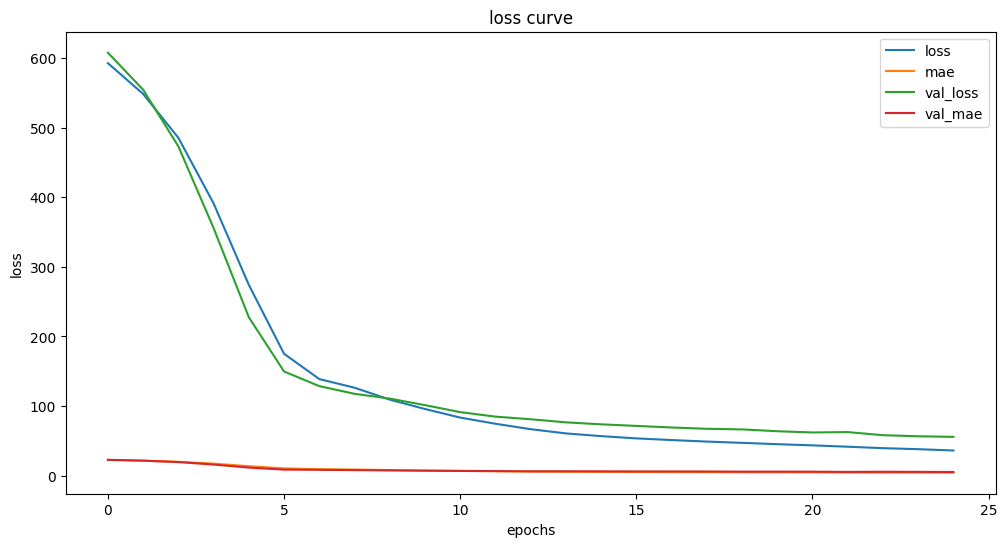

In [26]:
!pip install matplotlib
pd.DataFrame(history.history).plot(figsize=(12,6),xlabel="epochs",ylabel="loss",title="loss curve")

In [ ]:
y_pred=model.predict(